In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
data = pd.read_csv("customer_behavior.csv")

In [4]:
data.head()

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A


In [5]:
data.tail()

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
4995,5996,Female,West,1497.00,Electronics,Yes,B
4996,5997,Male,West,978.87,Fashion,Yes,A
4997,5998,Male,West,906.93,Fashion,No,NaN
4998,5999,Female,South,375.67,Fashion,No,NaN
4999,6000,Female,North,1392.74,Grocery,Yes,B


In [8]:
data = data.dropna(subset=['PurchaseAmount'])

#### 1.What is the average, median, and mode of PurchaseAmount?

In [9]:
data['PurchaseAmount'].mean()

np.float64(1003.9506701030928)

In [10]:
data['PurchaseAmount'].median()

998.0799999999999

In [11]:
data['PurchaseAmount'].mode()

0    0.0
Name: PurchaseAmount, dtype: float64

#### 2.Are there any outliers in the PurchaseAmount data?

In [12]:
q1,q2,q3 = np.percentile(data['PurchaseAmount'],[25,50,75])

In [13]:
q1,q2,q3

(np.float64(673.6424999999999),
 np.float64(998.0799999999999),
 np.float64(1327.0775))

In [14]:
iqr=q3-q1

In [15]:
iqr

np.float64(653.4350000000002)

In [16]:
lower=q1-(1.5*iqr)

In [17]:
lower

np.float64(-306.51000000000033)

In [18]:
higher= q3+(1.5*iqr)

In [19]:
higher

np.float64(2307.2300000000005)

In [20]:
np.where(data['PurchaseAmount']<lower)

(array([], dtype=int64),)

In [21]:
np.where(data['PurchaseAmount']>higher)

(array([ 186,  253,  333,  394,  787, 1306, 2210, 2474, 2596, 3216, 3325,
        3447, 4212, 4553, 4664]),)

<Axes: xlabel='PurchaseAmount'>

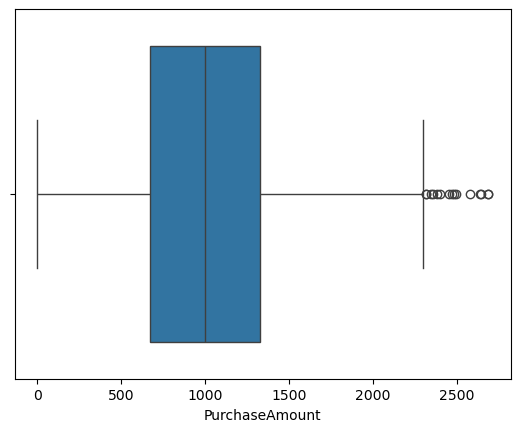

In [22]:
sns.boxplot(x=data['PurchaseAmount'])

### Yes, PurchaseAmount data has outliers.

### 3. Is there any skewness or kurtosis in the PurchaseAmount distribution?

In [23]:
data.skew(numeric_only=True)

CustomerID       -0.004534
PurchaseAmount    0.106092
dtype: float64

In [ ]:
#almost symmetric

In [24]:
data.kurtosis(numeric_only=True)

CustomerID       -1.199326
PurchaseAmount   -0.261511
dtype: float64

In [25]:
# flatter

<Axes: xlabel='PurchaseAmount', ylabel='Count'>

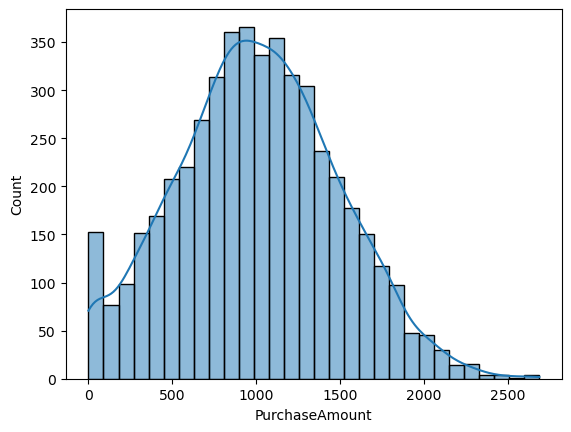

In [26]:
sns.histplot(data['PurchaseAmount'], bins=30, kde=True)

### 4. Is there a significant difference in spending between male and female customers?

In [28]:
print(data['Gender'].unique())

['Male' 'Female' nan]


In [29]:
data.dropna(subset=['PurchaseAmount', 'Gender'], inplace=True)

In [30]:
male_spend = data[data['Gender'] == 'Male']['PurchaseAmount']
female_spend = data[data['Gender'] == 'Female']['PurchaseAmount']

In [35]:
t_stat, p_val = stats.ttest_ind(male_spend, female_spend)

In [36]:
t_stat

np.float64(2.234885143428604)

In [37]:
 p_val

np.float64(0.025471167149519254)

In [39]:
alpha = 0.05
if p_val < alpha:
    print("Reject H0: Significant difference in spending between male and female customers.") #H1
else:
    print("Fail to reject H0: No significant difference between the male and female.")

Reject H0: Significant difference in spending between male and female customers.


### 5. Is there a relationship between ProductCategory and customer churn?

In [42]:
from scipy.stats import chi2_contingency

In [43]:
data['ProductCategory'].unique()

array(['Fashion', 'Electronics', 'Grocery', nan], dtype=object)

In [44]:
data['Churn'].unique()

array(['No', 'Yes', nan], dtype=object)

In [47]:
contingency = pd.crosstab(data['ProductCategory'], data['Churn'])

In [48]:
contingency

Churn,No,Yes
ProductCategory,,
Electronics,785,541
Fashion,839,607
Grocery,855,604


In [51]:
chi2, p, dof, expected = chi2_contingency(contingency)

In [52]:
print("Chi-square value:", chi2)
print("p-value:", p)
print(dof)
print(expected)

Chi-square value: 0.3960436652673918
p-value: 0.8203519424988512
2
[[776.9212952  549.0787048 ]
 [847.23091468 598.76908532]
 [854.84779012 604.15220988]]


In [54]:
alpha = 0.05
if p < alpha:
    print("Reject Null Hypothesis: There is a relationship between ProductCategory and customer churn")
else:
    print("Fail to Reject Null Hypothesis: No significant relationship.")

Fail to Reject Null Hypothesis: No significant relationship.


### 6. Does PurchaseAmount vary significantly across different regions?

In [55]:
data['Region'].value_counts()

Region
South    1248
East     1226
North    1211
West     1140
Name: count, dtype: int64

In [60]:
groups = [group['PurchaseAmount'].dropna() for name, group in data.groupby('Region')]

In [62]:
f_statistic, p_value = stats.f_oneway(*groups)

In [63]:
f_statistic

np.float64(0.38966786354806704)

In [64]:
 p_value

np.float64(0.760452802731563)

In [90]:
alpha = 0.05
if p_value < alpha:
    print("Reject Null Hypothesis:There is a significant difference in average purchase amount between regions")
else:
    print("Fail to Reject Null Hypothesis:There is no significant difference; purchase amounts are roughly similar across regions.")


Fail to Reject Null Hypothesis:There is no significant difference; purchase amounts are roughly similar across regions.


### 7. Which email campaign (A or B) performed better in terms of average PurchaseAmount?

In [67]:
import statsmodels.api as sm

In [68]:
groupA = data[data['CampaignGroup'] == 'A']['PurchaseAmount'].dropna()
groupB = data[data['CampaignGroup'] == 'B']['PurchaseAmount'].dropna()

In [80]:
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(groupA, groupB,equal_var=False)

In [81]:
t_stat

np.float64(1.2430861943551852)

In [82]:
p_value

np.float64(0.21389858277292212)

In [83]:
alpha = 0.05
if p_value < alpha:
    print("Reject Null Hypothesis:Statistically significant difference → one campaign performed bet")
else:
    print("Fail to Reject Null Hypothesis:No significant difference → both campaigns performed similarly..")


Fail to Reject Null Hypothesis:No significant difference → both campaigns performed similarly..


### 8. Can we assume PurchaseAmount follows a normal distribution?

<Axes: xlabel='PurchaseAmount', ylabel='Count'>

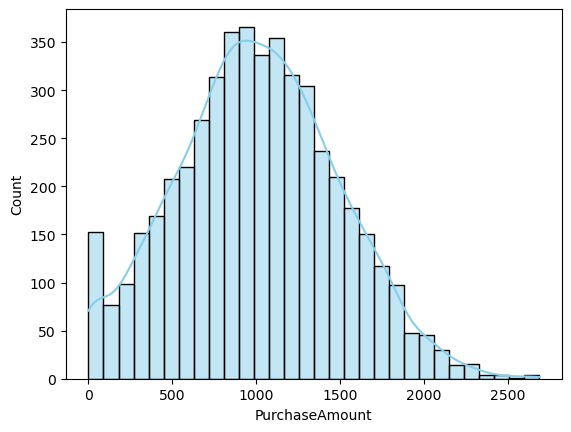

In [84]:
sns.histplot(data['PurchaseAmount'], kde=True, bins=30, color='skyblue')

In [86]:
data['PurchaseAmount'].skew()
data.skew(numeric_only=True)

CustomerID        0.000000
PurchaseAmount    0.106092
dtype: float64

***-0.5 to 0.5 Symmetric, hence PurchaseAmount follows a normal distribution.***

In [88]:
from scipy.stats import normaltest
stat, p = normaltest(data['PurchaseAmount'].dropna())

In [89]:
alpha = 0.05
if p_value > alpha:
    print("no significant deviation (data is roughly symmetric and normal).")
else:
    print("significant deviation (data likely skewed or heavy/light-tailed).")


no significant deviation (data is roughly symmetric and normal).


### 9. What insights can we gain by applying the Central Limit Theorem?

When we take many random samples from any population (even if it’s skewed or not normal) and calculate their means,
the distribution of those sample means will approach a normal distribution as the sample size increases.CLT allows us to use statistical tests and assume normality.Estimate the population mean and calculate confidence intervals.CLT provides the foundation for reliable decision-making and data-driven insights.

(array([ 1.,  5.,  2.,  7., 12., 17., 23., 32., 49., 54., 64., 74., 76.,
        97., 93., 80., 57., 59., 49., 49., 37., 20., 19., 13.,  5.,  1.,
         2.,  2.,  0.,  1.]),
 array([ 796.0682    ,  810.82825333,  825.58830667,  840.34836   ,
         855.10841333,  869.86846667,  884.62852   ,  899.38857333,
         914.14862667,  928.90868   ,  943.66873333,  958.42878667,
         973.18884   ,  987.94889333, 1002.70894667, 1017.469     ,
        1032.22905333, 1046.98910667, 1061.74916   , 1076.50921333,
        1091.26926667, 1106.02932   , 1120.78937333, 1135.54942667,
        1150.30948   , 1165.06953333, 1179.82958667, 1194.58964   ,
        1209.34969333, 1224.10974667, 1238.8698    ]),
 <BarContainer object of 30 artists>)

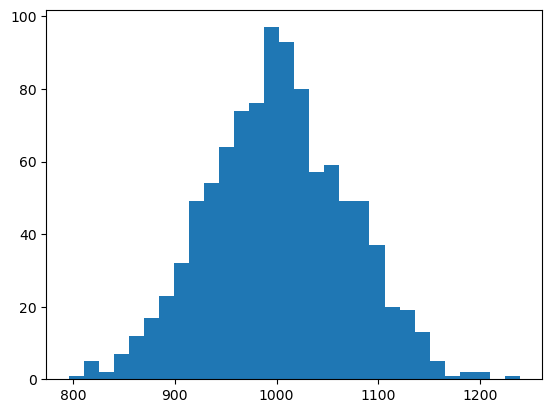

In [8]:
sample_means = []
for i in range(1000):
    sample = data['PurchaseAmount'].dropna().sample(50, replace=True)
    sample_means.append(sample.mean())
plt.hist(sample_means, bins=30)

This proves the Central Limit Theorem and justifies using parametric statistical tests

### 10.What is the 95% confidence interval for the average PurchaseAmount?

In [13]:
mean = data['PurchaseAmount'].mean()
std = data['PurchaseAmount'].std()
n = data['PurchaseAmount'].count
purchase = data['PurchaseAmount'].dropna()
confidence = 0.95
sem = stats.sem(purchase)   

ci = stats.t.interval(confidence, len(purchase)-1, loc=mean, scale=sem)
print(f"95% Confidence Interval for PurchaseAmount: {ci}")

95% Confidence Interval for PurchaseAmount: (np.float64(990.3789594609216), np.float64(1017.522380745264))
